# Digitization of Olfaction: Synthesizing Structural and Vibrational Dimensions
**Author:** Alan Pham  
**Program:** Neuroscience Major, DCS Minor; Bates College  
**Advisor:** Jason Castro  
**Semester:** Winter 2026

### Overview
This notebook computationally investigates whether molecular vibration (infrared spectral data) contains independent, predictive information that complements traditional structural models when mapping chemical stimuli to human perceptual categories. We evaluate three specific feature spaces:
1. **The "Shape" Baseline:** A structural model trained exclusively on 2D/3D topological descriptors.
2. **The "Shake" Baseline:** A vibrational model trained exclusively on continuous infrared (IR) transmission spectra.
3. **The Combined Model:** A unified matrix synthesizing both structural geometry and resonant energy.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from pathlib import Path

# scikit-learn tools
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, log_loss, roc_curve, auc
from sklearn.feature_selection import VarianceThreshold

# RDKit & Mordred (for Pyrfume features)
from rdkit import Chem
from mordred import Calculator, descriptors

DATA_DIR = Path("data")

### 1. Data Loading and Target Definition
We use crowdsourced psychophysical sensory evaluations from the DREAM Olfaction Prediction Challenge dataset (Keller et al., 2017). 

**Biological Filtering:** Human olfactory perception is highly sensitive to concentration; a molecule's scent profile can change drastically depending on its dose (e.g., Indole smells floral at low doses but putrid at high doses). To reduce this concentration-dependent noise, we explicitly filter the dataset to only include high-concentration stimuli (0.001 dilution).

**Target Variable:** Because human smell is subjective and multi-faceted, we use a single target variable (`dominant_percept`) for each molecule by identifying the specific perceptual descriptor (out of 20) that received the highest human rating.

loading data
Total overlapping high-concentration molecules: 207
---exploratory analysis---


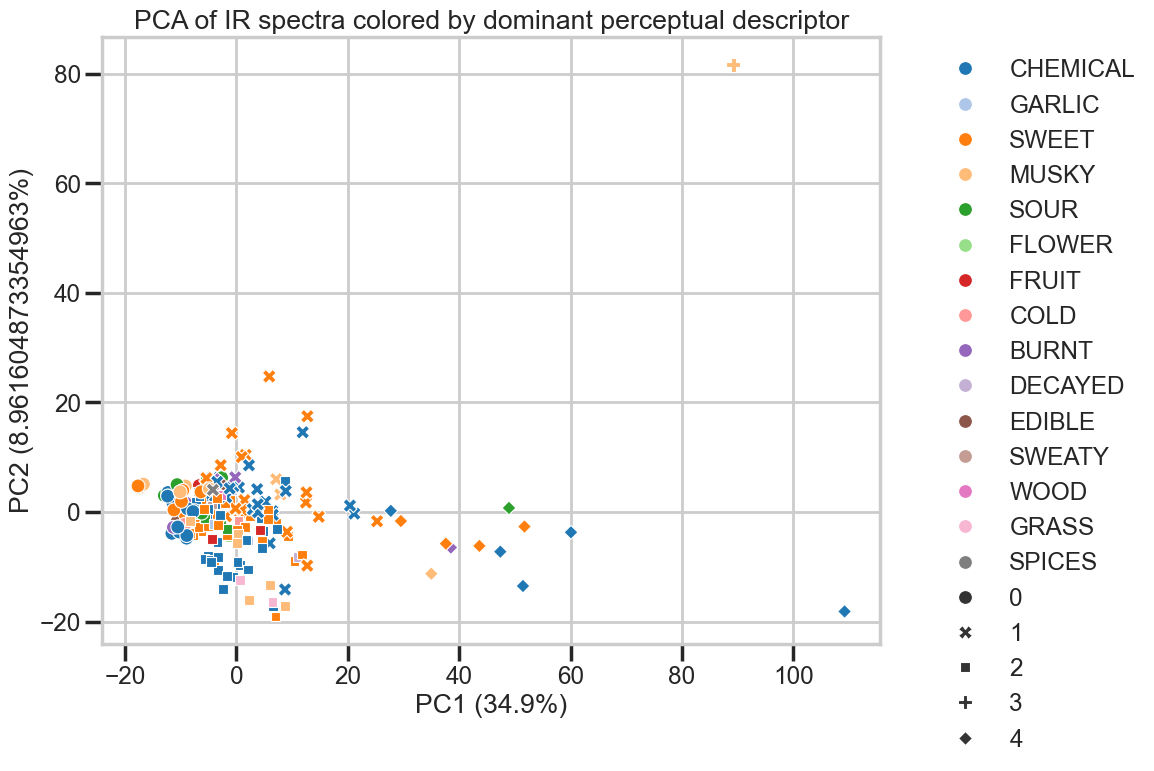

---calculating mordred features---
---classification task---
original class distribution:  dominant_percept
CHEMICAL    88
SWEET       64
SOUR        15
MUSKY       14
BURNT        5
EDIBLE       4
GARLIC       3
FRUIT        3
DECAYED      3
COLD         2
GRASS        2
FLOWER       1
SWEATY       1
WOOD         1
SPICES       1
Name: count, dtype: int64
dropped 10 rare classes
(186,)


In [11]:
# load data and prep
print("loading data")
qualities  = pd.read_csv(DATA_DIR / "keller_qualities.csv")
ir_spectra = pd.read_csv(DATA_DIR / "ir_spectra_matrix.csv", index_col=0)
molecules  = pd.read_csv(DATA_DIR / "molecules.csv")

# filter for high concentration only
qualities = qualities[qualities['Concentration'] == 0.001].copy()

# find dominant descriptor (target y for classification)
# drop metadata columns to isolate 20 descriptor ratings
desc_cols = [c for c in qualities.columns if c not in ['Stimulus', 'CID', 'Concentration']]
# find column name with highest value for each row
qualities['dominant_percept'] = qualities[desc_cols].idxmax(axis=1)

# merge percepts with IR spectra
df_merged = pd.merge(qualities[['CID', 'dominant_percept']], ir_spectra, on="CID", how='inner')

# find intersection of CIDs
valid_cids = df_merged['CID'].unique()
print(f"Total overlapping high-concentration molecules: {len(valid_cids)}")


# exploratory analysis (PCA and clustering)
print("---exploratory analysis---")

# isolate IR features 
X_ir_raw = df_merged.drop(columns=['CID', 'dominant_percept'])

# standardize before PCA
scaler_ir = StandardScaler()
X_ir_scaled = scaler_ir.fit_transform(X_ir_raw)

# PCA on IR spectra
pca = PCA(n_components = 2)
ir_pca = pca.fit_transform(X_ir_scaled)

# cluster IR spectra
kmeans = KMeans(n_clusters=5, random_state=42)
ir_clusters = kmeans.fit_predict(X_ir_scaled)

# plotting - paint perceptual labels onto IR PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(x=ir_pca[:, 0], y=ir_pca[:, 1], hue=df_merged['dominant_percept'], style=ir_clusters, palette='tab20', s=100)
plt.title("PCA of IR spectra colored by dominant perceptual descriptor")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# feature engineering (mordred / pyrfume)
print("---calculating mordred features---")
# filter molecules
mols_subset = molecules[molecules['CID'].isin(valid_cids)].copy()

# initialize mordred calc
calc = Calculator(descriptors, ignore_3D=True) 
# 2D features are faster and more robust


def get_mordred(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        try:
            return list(calc(mol))
        except:
            pass
    return [0] * len(calc.descriptors)


# calc features
features_list = mols_subset['CanonicalSMILES'].apply(get_mordred)
mordred_df = pd.DataFrame(features_list.tolist(), index=mols_subset['CID'])
mordred_df = mordred_df.apply(pd.to_numeric, errors='coerce').fillna(0) # to clean errors
mordred_df = mordred_df.reset_index()

# merge into master dataframe
master_df = pd.merge(df_merged, mordred_df, on='CID', how='inner')


# prediction task (classification showdown)
print("---classification task---")

# check distribution of classes
class_counts = master_df['dominant_percept'].value_counts()
print("original class distribution: ", class_counts)

# filter rare classes (classes must have at least 5 examples)
min_samples = 5
valid_classes = class_counts[class_counts >= min_samples].index

# apply filter
master_df = master_df[master_df['dominant_percept'].isin(valid_classes)].copy()
print(f"dropped {len(class_counts) - len(valid_classes)} rare classes")

# encode target labels to ints
le = LabelEncoder()
y = le.fit_transform(master_df['dominant_percept'])
print(y.shape)

# define feature spaces
X_ir       = master_df[X_ir_raw.columns]
X_shape    = master_df[mordred_df.columns.drop('CID')]
X_combined = pd.concat([X_shape, X_ir], axis=1)

### 3. Function for pipline
This function is used as the pipeline organizer for specific experimental conditions (i.e. testing independent or combined features). instead of rewriting data-splitting and model training, this function has the workflow in a loop.  
    splits data into training and testing sets (80/20)  
    scales/standarizes features to ensure model treats all numerical inputs the same  
    initializes and fits ML model on training data   

**input:**  
&nbsp;   feature matrix (X)  
&nbsp;   target labels (y)  
**returns:**  
&nbsp;   trained model  
&nbsp;   test data  
&nbsp;   prediction probabilies  

In [12]:
def evaluate_scenario(X, y, scenario_name, k_features=50):
    print(f"evaluating scenario: {scenario_name}")

    X.columns = X.columns.astype(str)

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # remove constant features (errors with UserWarning and RuntimeWarnings)
    selector_var = VarianceThreshold(threshold=0.0)
    X_train_v = selector_var.fit_transform(X_train)
    X_test_v  = selector_var.transform(X_test)

    # standardize
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_v)
    X_test_s  = scaler.transform(X_test_v)
    
    # feature selection
    # make sure k_features aren't bigger than remaining valid features
    k_actual = min(k_features, X_train_s.shape[1])
    selector  = SelectKBest(score_func=f_classif, k=k_actual)
    X_train_k = selector.fit_transform(X_train_s, y_train)
    X_test_k  = selector.transform(X_test_s)

    # model: random forest (calc cross-entropy with predict_proba)
    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train_k, y_train)

    # predictions
    y_pred  = clf.predict(X_test_k)
    y_proba = clf.predict_proba(X_test_k)

    # metrics
    loss = log_loss(y_test, y_proba)
    # AUROC needs one v rest for multi class
    try:
        auroc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    except ValueError:
        auroc = np.nan # handles edge cases where class is missing in test set


    print(f"cross-entropy loss: {loss:.4f}")
    print(f"AUROC (one v rest): {auroc:.4f}")

    # classification results (precision, recall, f1)
    print("---classification results---")
    target_names = le.inverse_transform(np.unique(y))
    print(classification_report(y_test, y_pred, target_names=le.inverse_transform(np.unique(y)), zero_division=0))

    # plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f"confusion matrix: {scenario_name}")
    plt.ylabel('actual')
    plt.xlabel('predicted')
    plt.tight_layout()
    plt.show()


evaluating scenario: 1. Physicochemical Only (Mordred)
cross-entropy loss: 3.6697
AUROC (one v rest): 0.5971
---classification results---
              precision    recall  f1-score   support

       BURNT       0.00      0.00      0.00         1
    CHEMICAL       0.61      0.78      0.68        18
       MUSKY       0.50      0.33      0.40         3
        SOUR       0.50      0.33      0.40         3
       SWEET       0.73      0.62      0.67        13

    accuracy                           0.63        38
   macro avg       0.47      0.41      0.43        38
weighted avg       0.62      0.63      0.61        38



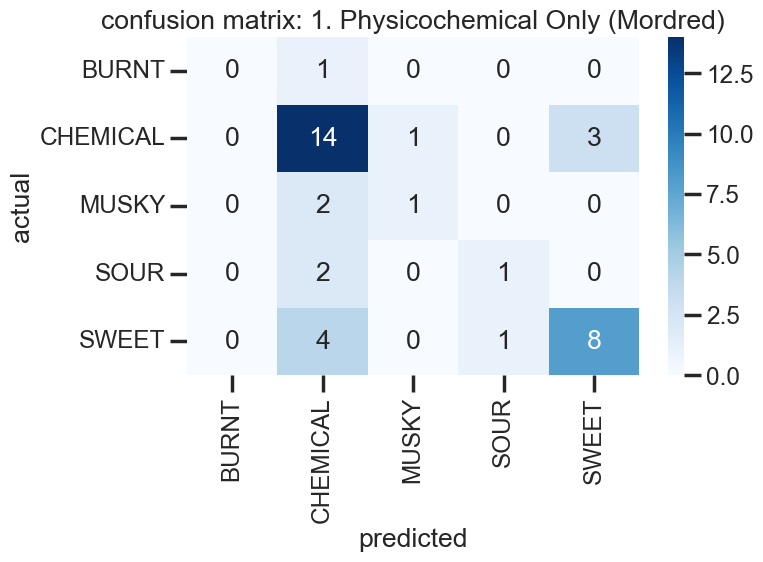

evaluating scenario: 2. Spectral Data Only (IR)
cross-entropy loss: 1.3657
AUROC (one v rest): 0.5943
---classification results---
              precision    recall  f1-score   support

       BURNT       0.00      0.00      0.00         1
    CHEMICAL       0.50      0.72      0.59        18
       MUSKY       0.00      0.00      0.00         3
        SOUR       0.00      0.00      0.00         3
       SWEET       0.30      0.23      0.26        13

    accuracy                           0.42        38
   macro avg       0.16      0.19      0.17        38
weighted avg       0.34      0.42      0.37        38



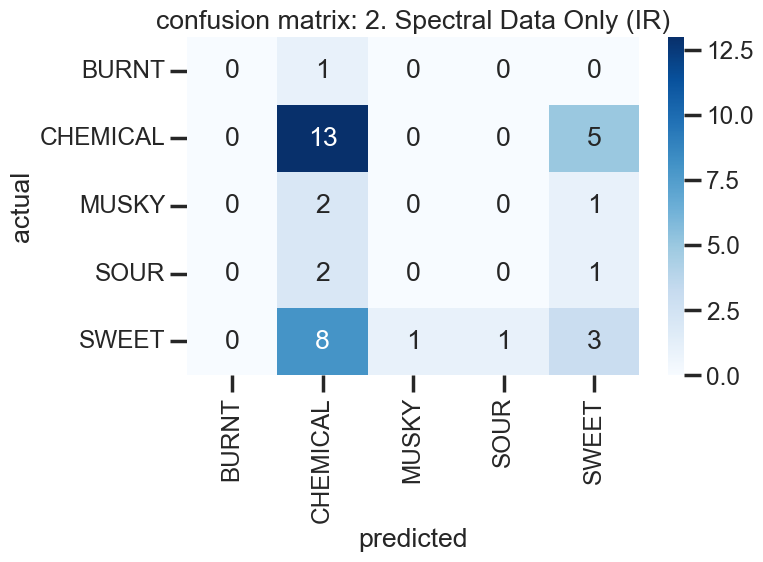

evaluating scenario: 3. Combined (Mordred + IR)
cross-entropy loss: 1.0230
AUROC (one v rest): 0.7759
---classification results---
              precision    recall  f1-score   support

       BURNT       0.00      0.00      0.00         1
    CHEMICAL       0.52      0.67      0.59        18
       MUSKY       0.00      0.00      0.00         3
        SOUR       0.00      0.00      0.00         3
       SWEET       0.46      0.46      0.46        13

    accuracy                           0.47        38
   macro avg       0.20      0.23      0.21        38
weighted avg       0.41      0.47      0.44        38



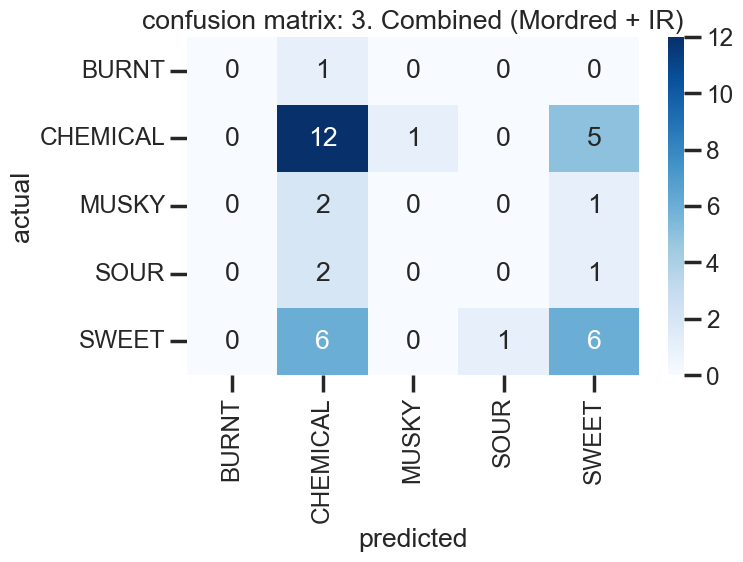

In [13]:
# run 3 scenarios
evaluate_scenario(X_shape, y, "1. Physicochemical Only (Mordred)", k_features=50)
evaluate_scenario(X_ir, y, "2. Spectral Data Only (IR)", k_features=50)
evaluate_scenario(X_combined, y, "3. Combined (Mordred + IR)", k_features=100)

### 4. Extractiong Metrics from the Model  
This function takes the perfromance of a trained model by comparing its predictions against the actual ground-truth table. It isolates the mathematical evoluation step from the training step.  
**inputs:**  
&nbsp; true test labels (y_test)  
&nbsp; model's prediction outputs (discrete class predictions or probability matrices)  
calculates classification metrics: computing OVR Macro AUROC score, also Log Loss, F1-scores, or create Confusion Matrix  
**Returns:**  
&nbsp; auroc  
&nbsp; y_test  
&nbsp; y_proba  
&nbsp; clf  
&nbsp; final_feature_names

In [14]:
def extract_model_metrics(X, y, k_features=50):
    """Helper function to run the pipeline and return exact metrics for plotting."""
    X.columns = X.columns.astype(str)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Variance threshold
    selector_var = VarianceThreshold(threshold=0.0)
    X_train_v = selector_var.fit_transform(X_train)
    X_test_v  = selector_var.transform(X_test)
    
    # Standardize
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_v)
    X_test_s  = scaler.transform(X_test_v)
    
    # Feature selection
    k_actual = min(k_features, X_train_s.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k_actual)
    X_train_k = selector.fit_transform(X_train_s, y_train)
    X_test_k  = selector.transform(X_test_s)
    
    # Train Random Forest
    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train_k, y_train)
    
    # Probabilities & AUROC
    y_proba = clf.predict_proba(X_test_k)
    try:
        auroc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    except ValueError:
        auroc = np.nan
        
    # Extract the names of the features that survived the SelectKBest
    surviving_var_features = X.columns[selector_var.get_support()]
    final_feature_names = surviving_var_features[selector.get_support()]
        
    return auroc, y_test, y_proba, clf, final_feature_names


--- Extracting Real Data for Poster Graphs ---
Generating AUROC Comparison Chart...


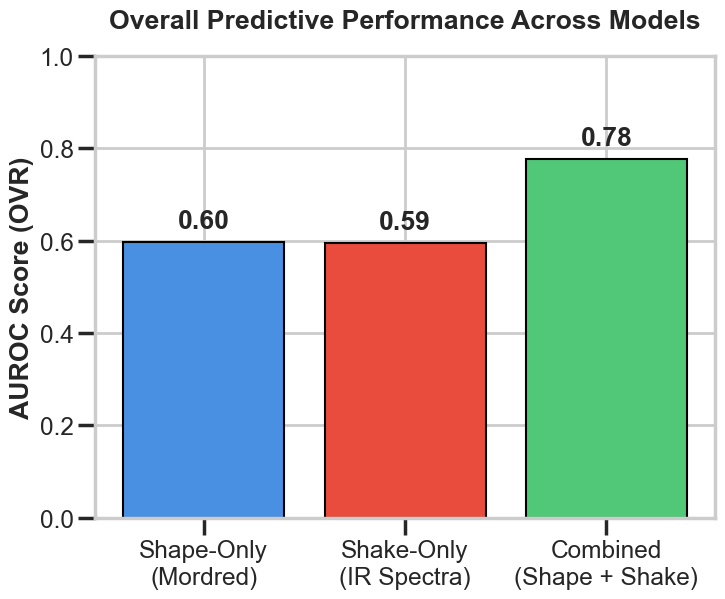

Generating ROC Curves...


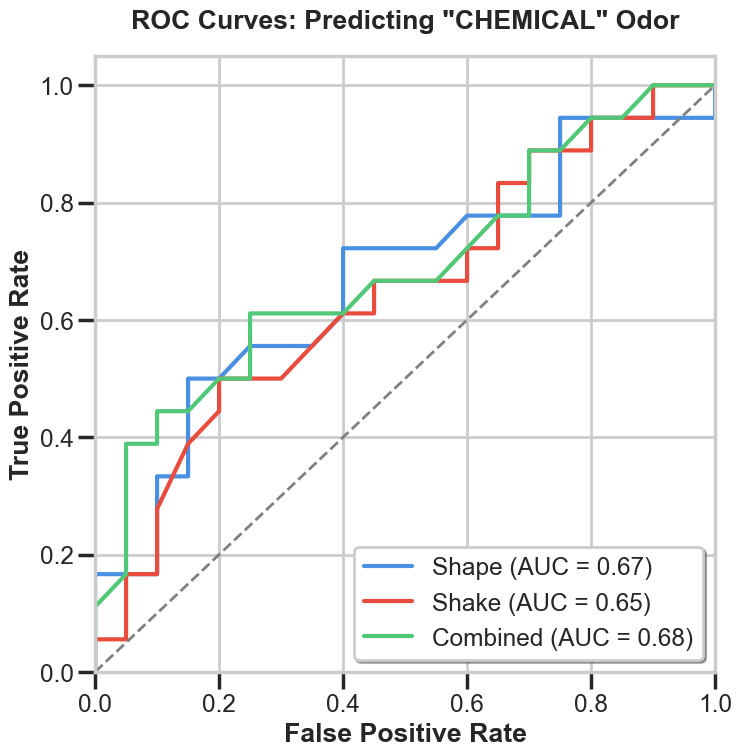

Generating Feature Importance Chart...


C:\Users\Drago\AppData\Local\Temp\ipykernel_25276\3824562690.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_feat_scores, y=top_feat_names, palette=bar_colors, edgecolor='black', ax=ax)


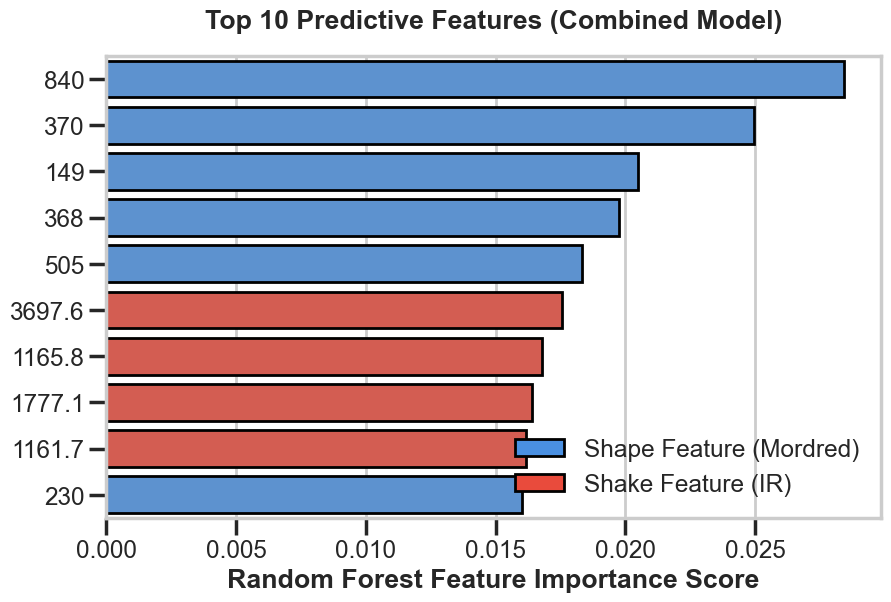

In [15]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("poster", font_scale=0.8)
colors = ['#4A90E2', '#E94B3C', '#50C878'] # Blue, Red, Green

print("\n--- Extracting Real Data for Poster Graphs ---")
# 1. Extract metrics for all three scenarios
auroc_shape, y_test_shape, proba_shape, _, _ = extract_model_metrics(X_shape, y, k_features=50)
auroc_ir, y_test_ir, proba_ir, _, _ = extract_model_metrics(X_ir, y, k_features=50)
auroc_comb, y_test_comb, proba_comb, clf_comb, feat_names_comb = extract_model_metrics(X_combined, y, k_features=100)

# ==========================================
# GRAPH 1: AUROC MODEL COMPARISON (BAR CHART)
# ==========================================
print("Generating AUROC Comparison Chart...")
models = ['Shape-Only\n(Mordred)', 'Shake-Only\n(IR Spectra)', 'Combined\n(Shape + Shake)']
auroc_scores = [auroc_shape, auroc_ir, auroc_comb] 

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(models, auroc_scores, color=colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    yval = bar.get_height()
    if not np.isnan(yval):
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', 
                ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, 1.0)
ax.set_ylabel('AUROC Score (OVR)', fontweight='bold')
ax.set_title('Overall Predictive Performance Across Models', fontweight='bold', pad=20)
plt.show()
plt.savefig('auroc_comparison_poster.png', dpi=300, bbox_inches='tight')
plt.close()

# ==========================================
# GRAPH 2: ROC CURVES FOR A SPECIFIC DESCRIPTOR
# ==========================================
print("Generating ROC Curves...")
# Find the index of the most common valid class to plot
target_class_idx = pd.Series(y_test_comb).value_counts().idxmax()
target_class_name = le.inverse_transform([target_class_idx])[0]

# Binarize the true labels for the specific class (1 if target class, 0 otherwise)
y_true_binary = (y_test_comb == target_class_idx).astype(int)

# Get the probabilities for just that class
prob_shape_class = proba_shape[:, target_class_idx]
prob_ir_class = proba_ir[:, target_class_idx]
prob_comb_class = proba_comb[:, target_class_idx]

fig, ax = plt.subplots(figsize=(8, 8))

# Shape
fpr_shape, tpr_shape, _ = roc_curve(y_true_binary, prob_shape_class)
ax.plot(fpr_shape, tpr_shape, color=colors[0], lw=3, label=f'Shape (AUC = {auc(fpr_shape, tpr_shape):.2f})')

# Shake (IR)
fpr_ir, tpr_ir, _ = roc_curve(y_true_binary, prob_ir_class)
ax.plot(fpr_ir, tpr_ir, color=colors[1], lw=3, label=f'Shake (AUC = {auc(fpr_ir, tpr_ir):.2f})')

# Combined
fpr_comb, tpr_comb, _ = roc_curve(y_true_binary, prob_comb_class)
ax.plot(fpr_comb, tpr_comb, color=colors[2], lw=3, label=f'Combined (AUC = {auc(fpr_comb, tpr_comb):.2f})')

ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'ROC Curves: Predicting "{target_class_name}" Odor', fontweight='bold', pad=20)
ax.legend(loc="lower right", frameon=True, shadow=True)
plt.show()
plt.savefig('roc_curve_specific_poster.png', dpi=300, bbox_inches='tight')
plt.close()

# ==========================================
# GRAPH 3: TOP 10 FEATURE IMPORTANCE 
# ==========================================
print("Generating Feature Importance Chart...")
# Get importances and tie them to feature names
importances = clf_comb.feature_importances_
feature_importance_dict = dict(zip(feat_names_comb, importances))

# Sort to get top 10
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_feat_names = [x[0] for x in sorted_features]
top_feat_scores = [x[1] for x in sorted_features]

fig, ax = plt.subplots(figsize=(10, 6))

# Color code based on origin (Shape vs Shake)
bar_colors = []
for feat in top_feat_names:
    if feat in X_shape.columns:
        bar_colors.append(colors[0]) # Blue for Shape
    else:
        bar_colors.append(colors[1]) # Red for Shake

sns.barplot(x=top_feat_scores, y=top_feat_names, palette=bar_colors, edgecolor='black', ax=ax)

ax.set_xlabel('Random Forest Feature Importance Score', fontweight='bold')
ax.set_title('Top 10 Predictive Features (Combined Model)', fontweight='bold', pad=20)

legend_elements = [Patch(facecolor=colors[0], edgecolor='black', label='Shape Feature (Mordred)'),
                   Patch(facecolor=colors[1], edgecolor='black', label='Shake Feature (IR)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.show()
plt.savefig('feature_importance_poster.png', dpi=300, bbox_inches='tight')
plt.close()